In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
import traceback
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

17030
17030


/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/query_decomposer.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.query_analyzer = LLMChain(llm=llm, prompt=self.prompt_builder, verbose=False)


In [2]:

llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = True # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: True, Database: mondial


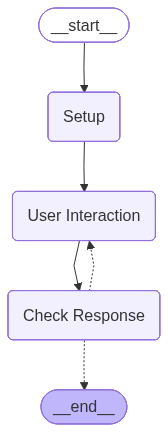

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]

    # Se o experimento já foi avaliado, pula para o próximo
    if exp_id in processed_ids:
        print(f"Pulando experimento {exp_id} já processado.")
        continue

    print(f"Processando experimento {exp_id}...")

    try:
        # Invoca a avaliação
        eval_result = eval_graph.invoke(
            {
                "experiment": experiment,
                "max_retries": 2,
                "debug_mode": True,
                "model_version": model_version,
                "experiment_type": experiment_type,
            },
            {"recursion_limit": 200}
        )

        print("Experimento avaliado:\n", eval_result["experiment_eval"])

        # Salva resultado
        evals.append({
            "experiment_id": exp_id,
            "experiment_config": eval_result.get(
                "experiment_config",
                {
                    "max_retries": 2,
                    "model_version": model_version,
                    "timestamp": datetime.now().isoformat(),
                    "experiment_type": experiment_type,
                }
            ),
            "experiment_eval": eval_result["experiment_eval"]
        })

    except Exception as e:
        print(f"\n Erro ao processar experimento {exp_id}: {e}")
        traceback.print_exc()

        # (Opcional) registra falha no arquivo de saída
        # evals.append({
        #     "experiment_id": exp_id,
        #     "experiment_config": {
        #         "model_version": model_version,
        #         "timestamp": datetime.now().isoformat(),
        #         "experiment_type": experiment_type,
        #     },
        #     "experiment_eval": None,
        #     "error": str(e)
        # })

    finally:
        # Atualiza o arquivo SEMPRE (sucesso ou erro)
        with open(evals_filename, 'w', encoding='utf-8') as f:
            json.dump(evals, f, indent=4)

Pulando experimento 1 já processado.
Pulando experimento 2 já processado.
Processando experimento 3...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  What are the different names of cities in the database?
Decomposition
['Retrieve all different names (other names) of cities from the database.', 'Quais são os diferentes nomes das cidades no banco de dados?']
(17030,)
(17030,)
DFE
Question: cities listed in database of cities
SELECT NAME FROM MONDIAL_CITY

Question: cities listed in database?
SELECT DISTINCT NAME FROM MONDIAL_CITY;

Question: Which cities are listed in the database of cities?
SELECT NAME FROM MONDIAL_CITY

Question: cities listed in database
SELECT NAME FROM MONDIAL_CITY

Question: What is the population of the cities in the database that contains information about different cities?
SELECT NAME, POPULATION FROM MONDIAL_CITY

Question: Which cities are listed in the database

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "Retrieve all different names (other names) of cities from the database.",
    "schema_linking": ["MONDIAL_CITYOTHERNAME"],
    "answer": "There are 523 different names (other names) of cities in the database, including examples such as Bisho, East London, Port Elizabeth, Bloemfontein, and East Rand.",
    "sql": "SELECT othername FROM mondial_gpt.cityothername"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Retrieve all different names (other names) of cities from the database.",
    "schema_linking": ["MONDIAL_CITYOTHERNAME"],
    "answer": "There are 523 different names (other names) of cities in the database, including examples such as Bisho, East London, Port Elizabeth, Bloemfontein, and East Rand.",
    "sql": "SELECT othername FROM mondial_gpt.cityothername"
}.

[INFO] Avaliando o resultado: {'input': 'Retrieve all different names (other names)

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


True cols: Index(['OTHERNAME'], dtype='object')
Adj. True cols: Index(['OTHERNAME'], dtype='object')
Predicted cols: Index(['OTHERNAME'], dtype='object')
Adj. Predicted cols: Index(['OTHERNAME'], dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 1, 'original_intent': 'List all the alternative names of cities.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'What are the different names of cities in the database?', 'agent_reply': 'There are 523 different names (other names) of cities in the database, including examples such as Bisho, East London, Port Elizabeth, Bloemfontein, and East Rand.', 'evaluation': {'text_to_sql_input': 'Retrieve all different names (other names) of cities from the database.', 'user_intention': 'List all the alternative names of cities.', 'recall': 0.0, 'alignment': True, 'correctness': True, 'expected_sql': 'SELECT OTHERNAME FROM MONDIAL_CITYOTHERNAME', 'generated_sql': 'SELECT othername FROM mondia

...

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


True cols: Index(['DESERT', 'PROVINCE'], dtype='object')
Adj. True cols: Index(['DESERT', 'PROVINCE'], dtype='object')
Predicted cols: Index(['PROVINCE', 'DESERT'], dtype='object')
Adj. Predicted cols: Index(['DESERT', 'PROVINCE'], dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 3, 'original_intent': 'Find the provinces associated with the deserts.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'For the deserts, what are their associated provinces?', 'agent_reply': 'The database lists various deserts and their associated provinces, such as Erg Maqteir in Adrar, Dascht-e-Margoh in Afghanistan, Rub Al Chali in Yemen, Chihuahua in Zacatecas, Tenere in Zinder, and Syrian Desert in al-Anbar, among others.', 'evaluation': {'text_to_sql_input': 'For the deserts listed in the database, what are their associated provinces?', 'user_intention': 'Find the provinces associated with the deserts.', 'recall': 0.0, 'alignment': True, 'co

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "What is the average area of the deserts?",
    "schema_linking": ["MONDIAL_DESERT"],
    "answer": "The average area of the deserts listed in the database is approximately 225,202.54 square kilometers.",
    "sql": "SELECT AVG(area) AS average_desert_area FROM mondial_gpt.desert"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "What is the average area of the deserts?",
    "schema_linking": ["MONDIAL_DESERT"],
    "answer": "The average area of the deserts listed in the database is approximately 225,202.54 square kilometers.",
    "sql": "SELECT AVG(area) AS average_desert_area FROM mondial_gpt.desert"
}.

[INFO] Avaliando o resultado: {'input': 'What is the average area of the deserts?', 'schema_linking': ['MONDIAL_DESERT'], 'answer': 'The average area of the deserts listed in the database is approximately 225,202.54 square kilometers.', 'sql': 'SELE

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
